In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))

if os.getcwd() != project_root:
    os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import pandas as pd
import time
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm 

from volatility_surface.core.calibration.calibrator import calibrate_snapshot, calibrate_global_essvi, calibrate_global_sabr, calibrate_global_essvi_update, summary, compare
from volatility_surface.core.calibration.objectives import get_objective
from volatility_surface.models.vol_models import get_model
from volatility_surface.plots.vol_plots import plot_surface, plot_slices, plot_total_variance, plot_metrics, plot_compare, plot_all
from time import time
import pandas as pd
pd.set_option('display.max_columns', None)
from volatility_surface.utils.arbitrage_checker import check_arbitrage, plot_arbitrage_map

def clean_df(path: str):
    """Cleans the market microstructure data
    #See if we only take otm options ? 'c' & k>0 otm calls, 'p' & k<0 otm puts

    Args:
        path (str): path of the file we want to use as the df 
    returns: pd.DataFrame
    """

    
    df = pd.read_csv(path)
    df = df[df.volume>0]
    put_boundary_mask = (df['underlying_price']*df['bid_price']<df['strike']) & (df['option_type']=='P')
    call_boundary_mask = (df['option_type']=='C') & (df['bid_price']<1)
    

    clean_df = df[put_boundary_mask | call_boundary_mask].copy()
    
    #Timestamp standardisation
    ts = clean_df.creation_timestamp_x.iloc[0]
    clean_df['creation_timestamp_x'] = ts
    clean_df['creation_timestamp_x'] = clean_df['creation_timestamp_x'] #2h, paris = gmt +2
    clean_df['expiration_timestamp'] = pd.to_datetime(df['expiration_timestamp'], format='%d%b%y')+pd.Timedelta(hours=8)
    clean_df['expiration_timestamp_ms'] = clean_df['expiration_timestamp'].astype('int64') / 10**6
    clean_df['file_timestamp'] = pd.to_datetime(clean_df['creation_timestamp_x'], unit='ms').dt.strftime('%Y-%m-%d %H:%M')

    #Features
    clean_df['mark_iv']= clean_df['mark_iv']/100
    clean_df['t'] = (clean_df['expiration_timestamp_ms']-clean_df['creation_timestamp_x'])/(3.6e6*24*365)
    clean_df['k'] = np.log(clean_df['strike']/clean_df['underlying_price'])
    clean_df['w'] = clean_df['mark_iv']**2 * clean_df['t'] 
    n_d1 = norm.pdf(-clean_df['k']/np.sqrt(clean_df['w']) + np.sqrt(clean_df['w'])/2) #Gatheral d1 formula, equivalent to classical one
    clean_df['vega'] = n_d1*np.sqrt(clean_df['t']) # Vega is to be multiplied by 1 vol point; Since we express vol as decimal, this is the adequate format
    #if we expressed vol as a percentage, we would divide vega by 100: e.g. 0.42 vol, 0.3 vega <=> 42 vol, 0.003 vega

    #OTM Filtering
    otm_call_mask = (clean_df.option_type=='C') & (clean_df.k >=0)
    otm_put_mask = (clean_df.option_type=='P') & (clean_df.k<=0)
    clean_df = clean_df[otm_call_mask | otm_put_mask]

    #IV Quotes
    clean_df[['bid_iv','ask_iv']] = clean_df.apply(implied_volatility_dataframe, axis=1, result_type='expand')
    clean_df.dropna(subset=['bid_iv','ask_iv'], inplace=True)
    clean_df['spread_iv'] = (clean_df['ask_iv'] - clean_df['bid_iv'])/2
    return clean_df



import glob
from pathlib import Path
def parquet_creation(underlying: str):
# Get all CSV files from data/ folder
    underlying=underlying.lower()
    csv_files = sorted(glob.glob(f'data/{underlying}/*.csv'))

    # Load and clean all CSV files
    global_df = pd.concat([clean_df(file) for file in csv_files], ignore_index=True)

    # Save to parquet
    global_df.to_parquet(f'data/parquets/{underlying}_options_data_cleaned.parquet')

eth_df = pd.read_parquet('2 - Data/parquets/eth_options_data_cleaned.parquet')
btc_df = pd.read_parquet('2 - Data/parquets/btc_options_data_cleaned.parquet')


eth_snapshots = {}
for t0 in eth_df.file_timestamp.unique():
    eth_snapshot = eth_df[eth_df.file_timestamp == t0]
    eth_snapshots[f'eth {eth_snapshot.file_timestamp.unique()[0]}'] = eth_snapshot
eth_dates = eth_snapshots.keys()

btc_snapshots = {}
for t0 in btc_df.file_timestamp.unique():
    btc_snapshot = btc_df[btc_df.file_timestamp == t0]
    btc_snapshots[f'btc {btc_snapshot.file_timestamp.unique()[0]}'] = btc_snapshot


eth = eth_snapshots['eth 2026-05-22 14:42']
eth_clean = eth[(eth.half_spread/eth.mark_price)<0.5]

In [6]:
from volatility_surface.core.calibration.objectives import OBJECTIVES
from time import time
dict_checking = {}
for k,v in OBJECTIVES.items():
    model = get_model('essvi')
    t0 = time()
    dict_checking[k] = calibrate_global_essvi(df=eth_clean, model=model, objective=v, bid_col='bid_iv',ask_col='ask_iv', verbose=False)
    t1 = time()
    print(k,f' calibration done in {round(t1-t0,2)}s')

w_mse  calibration done in 56.99s
iv_mse  calibration done in 60.28s
iv_wmse  calibration done in 57.79s
price_mse  calibration done in 128.54s
iv_rmse  calibration done in 49.98s
vega_wmse  calibration done in 83.79s
band  calibration done in 53.74s
vega_wmse_band  calibration done in 103.18s
iv_zweighted  calibration done in 99.14s
iv_uniform_z  calibration done in 66.04s
iv_convex_blend  calibration done in 94.29s
iv_replication  calibration done in 106.95s


In [5]:
from volatility_surface.core.calibration.objectives import obj_iv_zweighted
res_essvi_b04 = calibrate_global_essvi(df=eth_clean, model=get_model('essvi'), objective=obj_iv_zweighted, bid_col='bid_iv',ask_col='ask_iv',verbose=False)


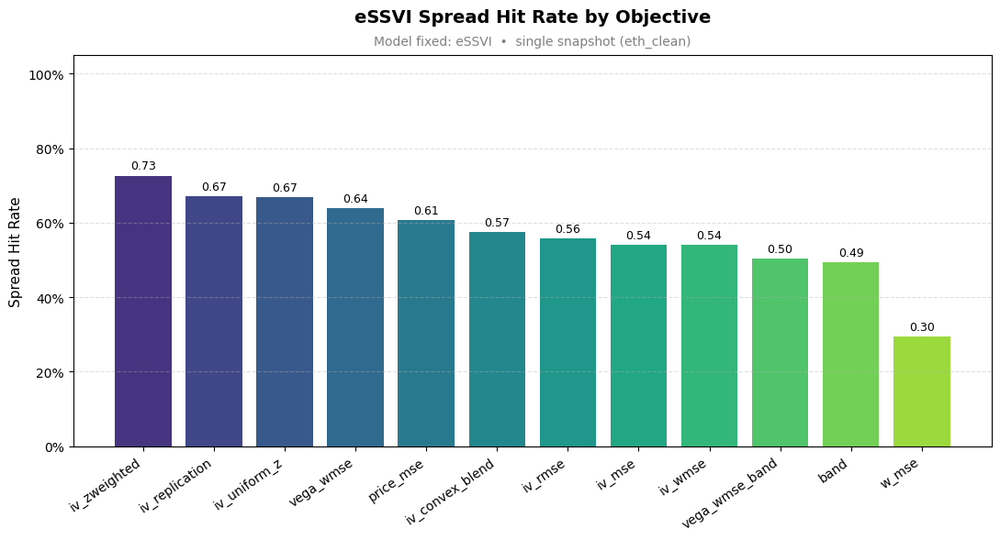

In [7]:
import numpy as np, matplotlib.pyplot as plt

hr = {k: np.nanmean(v['metrics']['spread_hit_rate']) for k, v in dict_checking.items()}
hr = dict(sorted(hr.items(), key=lambda kv: kv[1], reverse=True))   # best → worst

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(hr.keys(), hr.values(),
              color=plt.cm.viridis(np.linspace(0.15, 0.85, len(hr))))
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('eSSVI Spread Hit Rate by Objective', fontsize=14, fontweight='bold', pad=26)
ax.text(0.5, 1.02, 'Model fixed: eSSVI  •  single snapshot (eth_clean)',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='gray')
ax.set_ylabel('Spread Hit Rate', fontsize=11)
plt.xticks(rotation=35, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('essvi_hit_rate_by_objective.png', dpi=150, bbox_inches='tight')
plt.show()

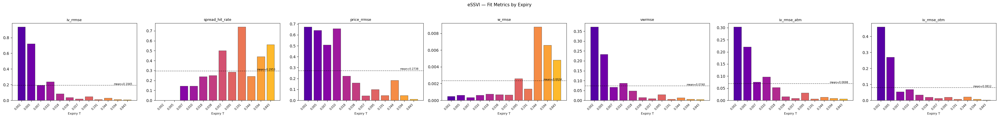

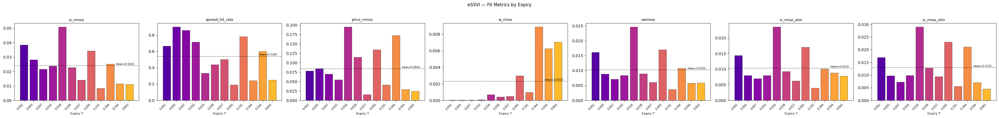

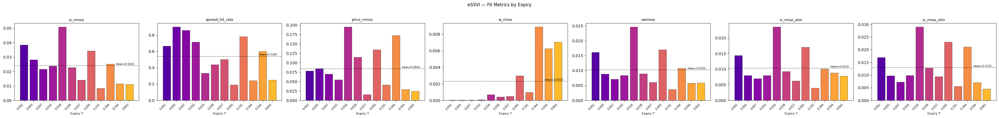

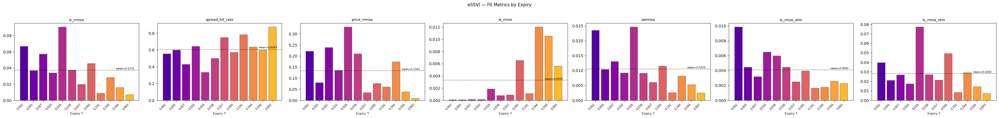

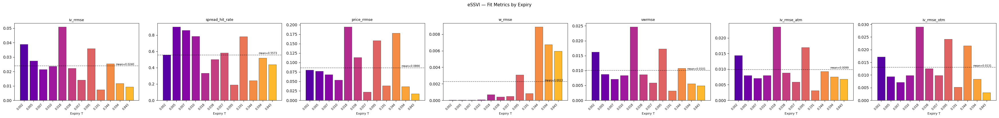

...

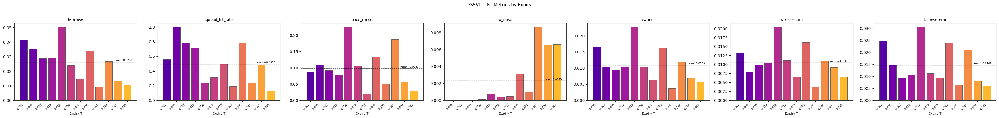

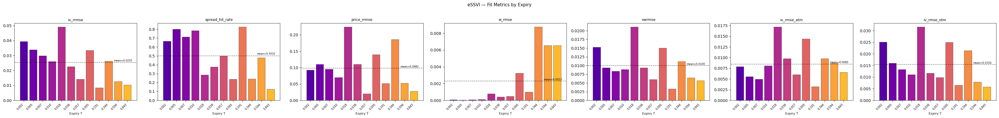

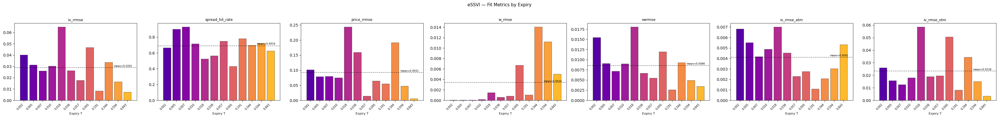

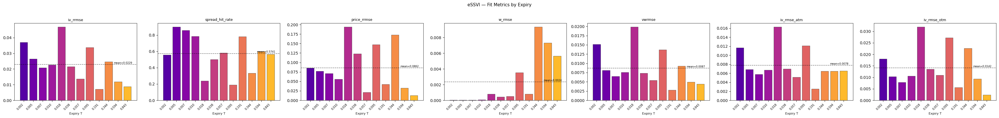

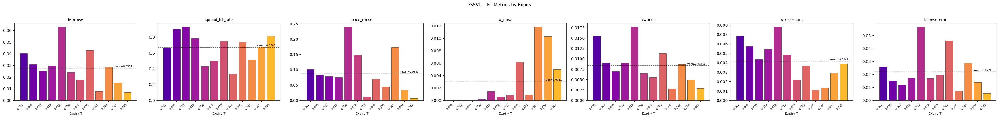

In [ ]:
for k,v in OBJECTIVES.items():
    plot_metrics(dict_checking[k])
    

In [81]:
obj = get_objective('vega_wmse')

comparison_dict = {}
eth_cal_arb_vio = {'Raw SVI':0,'eSSVI':0,'SABR':0}
btc_cal_arb_vio = {'Raw SVI':0,'eSSVI':0,'SABR':0}

eth_average_hit_rate = {'Raw SVI':0,'eSSVI':0,'SABR':0}
btc_average_hit_rate = {'Raw SVI':0,'eSSVI':0,'SABR':0}

eth_results_dict = {}
for date, snapshot in eth_snapshots.items():
    svi_vwmse = calibrate_snapshot(df=snapshot, model=get_model('svi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
    sabr_vwmse = calibrate_snapshot(df=snapshot, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
    essvi_vwmse = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)


    eth_results_dict[f'{date}_svi'] = svi_vwmse
    eth_results_dict[f'{date}_essvi'] = essvi_vwmse
    eth_results_dict[f'{date}_sabr'] = sabr_vwmse


    comparison = compare(svi_vwmse, sabr_vwmse, essvi_vwmse)
    comparison_dict[date[4:14]] = comparison
    eth_cal_arb_vio['Raw SVI'] += comparison.cal_arb_viol['Raw SVI']
    eth_cal_arb_vio['eSSVI'] += comparison.cal_arb_viol['eSSVI']
    eth_cal_arb_vio['SABR'] += comparison.cal_arb_viol['SABR']

    eth_average_hit_rate['Raw SVI'] += comparison.spread_hit_rate['Raw SVI']
    eth_average_hit_rate['eSSVI'] += comparison.spread_hit_rate['eSSVI']
    eth_average_hit_rate['SABR'] += comparison.spread_hit_rate['SABR']

                objective  iv_rrmse  spread_hit_rate  price_rrmse    w_rmse    vwrmse  iv_rmse_atm  iv_rmse_otm  cal_arb_viol  atm_smoothness
model                                                                                                                                        
Raw SVI  obj_iv_vega_wmse  0.006741         0.911780     0.056729  0.000631  0.001848     0.000628     0.005322           0.0        0.021456
SABR     obj_iv_vega_wmse  0.049592         0.496845     0.214685  0.004978  0.018165     0.013558     0.031782           0.0        0.021176
eSSVI    obj_iv_vega_wmse  0.039764         0.658887     0.194059  0.003523  0.012069     0.002876     0.034061           0.0        0.020918
                objective  iv_rrmse  spread_hit_rate  price_rrmse    w_rmse    vwrmse  iv_rmse_atm  iv_rmse_otm  cal_arb_viol  atm_smoothness
model                                                                                                                                        
Raw SV

In [1]:
import pickle
with open('vw_comparison_dict.pkl', 'wb') as f:
    pickle.dump(comparison_dict, f)

with open('vw_eth_cal_arb_vio.pkl', 'wb') as f:
    pickle.dump(eth_cal_arb_vio, f)

with open('vw_eth_average_hit_rate.pkl', 'wb') as f:
    pickle.dump(comparison_dict, f)

with open('vw_eth_results_dict.pkl','wb') as f:
    pickle.dump(eth_results_dict, f)

NameError: name 'comparison_dict' is not defined

Saved → spread_hit_rate.png


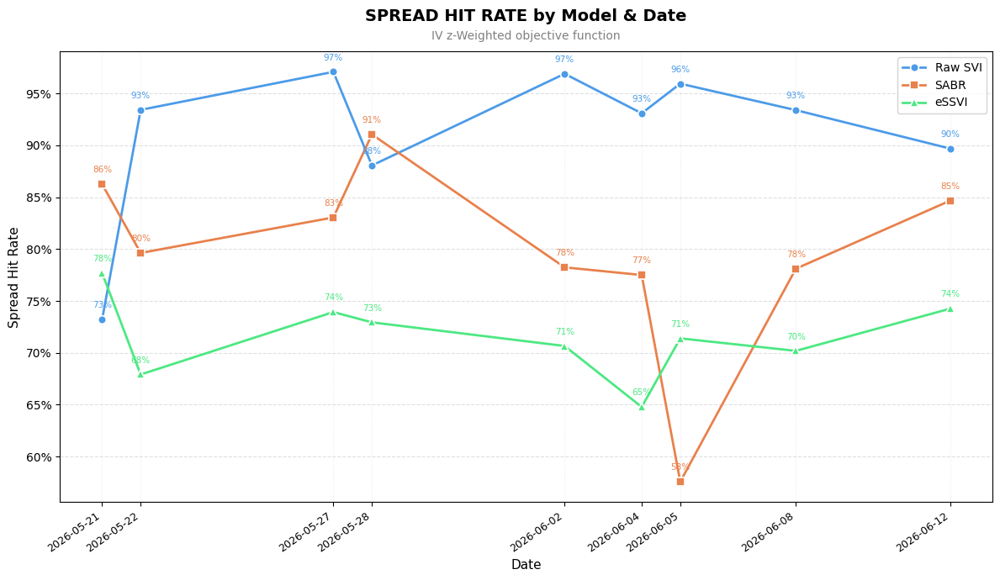

Saved → vwrmse.png


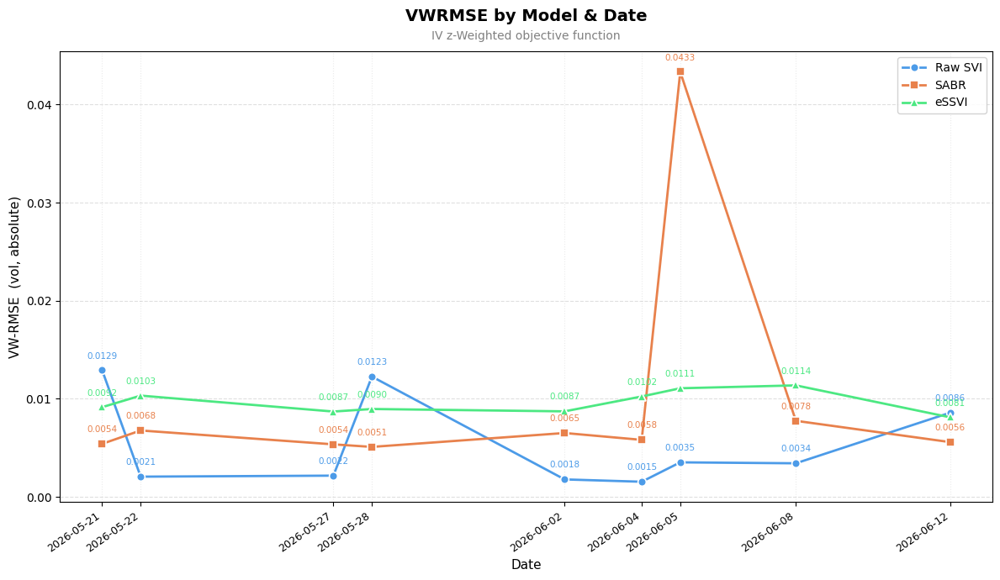

Saved → vwrmse_pct.png


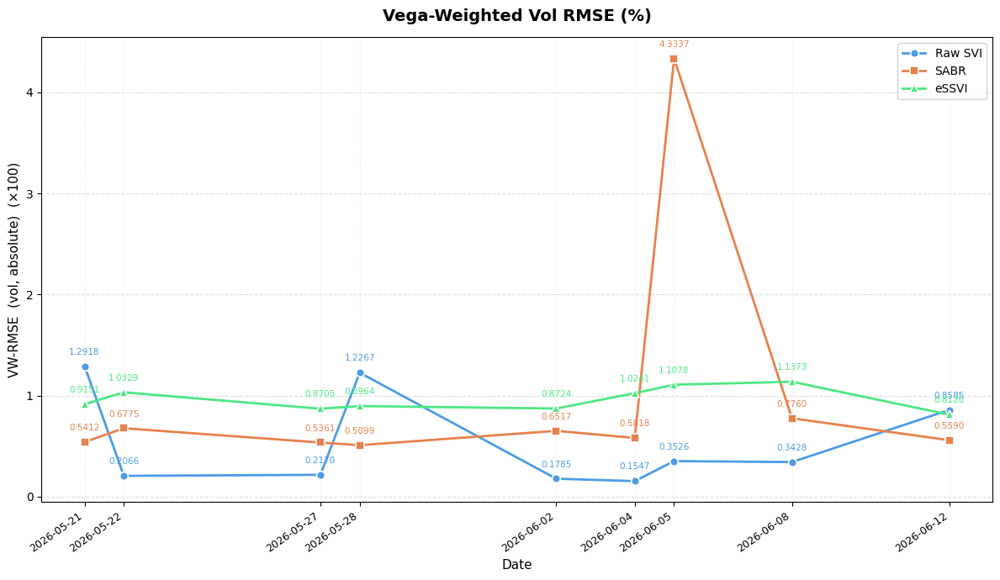

ValueError: Metric 'vwrrmse' not found on comparison objects.

In [5]:
from volatility_surface.plots.vol_plots import plot_metric_by_date


# Load the data
with open('ivz_comparison_dict.pkl', 'rb') as f:
    comparison_dict = pickle.load(f)
    
# your original plot — one line
plot_metric_by_date(comparison_dict, metric='spread_hit_rate',
                    subtitle='IV z-Weighted objective function',
                    savepath='spread_hit_rate.png')

# vwrmse in vol points (decimal)
plot_metric_by_date(comparison_dict, metric='vwrmse',
                    subtitle='IV z-Weighted objective function',
                    savepath='vwrmse.png')

# vwrmse scaled to %, annotated as 4-decimal floats
plot_metric_by_date(comparison_dict, metric='vwrmse', scale=100,
                    title='Vega-Weighted Vol RMSE (%)',
                    savepath='vwrmse_pct.png')

# relative version
plot_metric_by_date(comparison_dict, metric='vwrrmse')

# custom models / colors
plot_metric_by_date(comparison_dict, metric='iv_rrmse',
                    models=['Raw SVI', 'eSSVI'],
                    colors={'Raw SVI': '#4C9BE8', 'eSSVI': '#4CE882'})

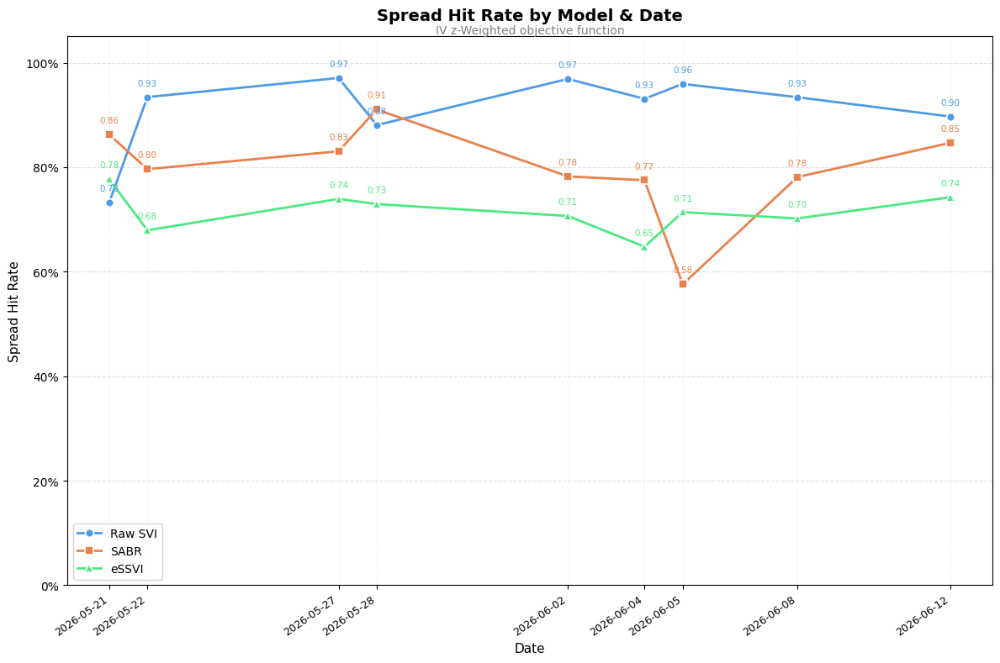

Saved → spread_hit_rate.png


In [109]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
with open('ivz_comparison_dict.pkl', 'rb') as f:
    comparison_dict = pickle.load(f)

# Extract dates and hit rates per model
dates = sorted(comparison_dict.keys())
dates_dt = [datetime.strptime(d, '%Y-%m-%d') for d in dates]

models = ['Raw SVI', 'SABR', 'eSSVI']
colors  = {'Raw SVI': '#4C9BE8', 'SABR': '#E8814C', 'eSSVI': '#4CE882'}
markers = {'Raw SVI': 'o',        'SABR': 's',        'eSSVI': '^'}

hit_rates = {m: [] for m in models}

for date in dates:
    hr = comparison_dict[date].spread_hit_rate
    for model in models:
        hit_rates[model].append(hr[model])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for model in models:
    ax.plot(
        dates_dt, hit_rates[model],
        label=model,
        color=colors[model],
        marker=markers[model],
        linewidth=2,
        markersize=7,
        markeredgewidth=1.2,
        markeredgecolor='white',
    )
    # Annotate each point with its value
    for x, y in zip(dates_dt, hit_rates[model]):
        ax.annotate(
            f'{y:.2f}',
            xy=(x, y),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=7.5,
            color=colors[model],
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax.set_title('Spread Hit Rate by Model & Date', fontsize=14, fontweight='bold', pad=14)
ax.text(0.5, 1.0, 'IV z-Weighted objective function', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.savefig('spread_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spread_hit_rate.png")

In [16]:
comparison_dict['2026-06-04']


,objective,iv_rrmse,spread_hit_rate,price_rrmse,w_rmse,vwrmse,iv_rmse_atm,iv_rmse_otm,cal_arb_viol,atm_smoothness
model,,,,,,,,,,
Raw SVI,obj_iv_zweighted,0.005826,0.930757,0.052343,0.000423,0.001547,0.000706,0.004299,0.0,0.021334
SABR,obj_iv_zweighted,0.018624,0.774973,0.113320,0.002044,0.005818,0.002882,0.014824,0.0,0.021112
eSSVI,obj_iv_zweighted,0.033400,0.647847,0.174376,0.002969,0.010241,0.004455,0.027949,0.0,0.020639


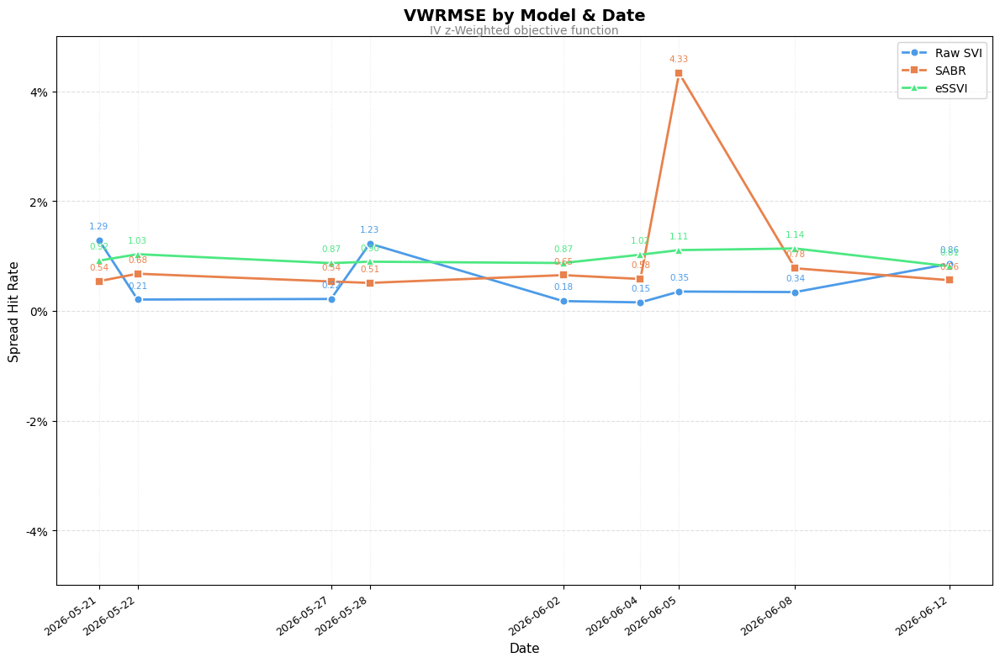

Saved → spread_hit_rate.png


In [24]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
with open('ivz_comparison_dict.pkl', 'rb') as f:
    comparison_dict = pickle.load(f)

# Extract dates and hit rates per model
dates = sorted(comparison_dict.keys())
dates_dt = [datetime.strptime(d, '%Y-%m-%d') for d in dates]

models = ['Raw SVI', 'SABR', 'eSSVI']
colors  = {'Raw SVI': '#4C9BE8', 'SABR': '#E8814C', 'eSSVI': '#4CE882'}
markers = {'Raw SVI': 'o',        'SABR': 's',        'eSSVI': '^'}

hit_rates = {m: [] for m in models}

for date in dates:
    hr = comparison_dict[date].vwrmse
    for model in models:
        hit_rates[model].append(hr[model])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for model in models:
    ax.plot(
        dates_dt, hit_rates[model],
        label=model,
        color=colors[model],
        marker=markers[model],
        linewidth=2,
        markersize=7,
        markeredgewidth=1.2,
        markeredgecolor='white',
    )
    # Annotate each point with its value
    for x, y in zip(dates_dt, hit_rates[model]):
        ax.annotate(
            f'{100*y:.2f}',
            xy=(x, y),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=7.5,
            color=colors[model],
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)

ax.set_ylim(0, 0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax.set_title('VWRMSE by Model & Date', fontsize=14, fontweight='bold', pad=14)
ax.text(0.5, 1.0, 'IV z-Weighted objective function', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.savefig('spread_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spread_hit_rate.png")

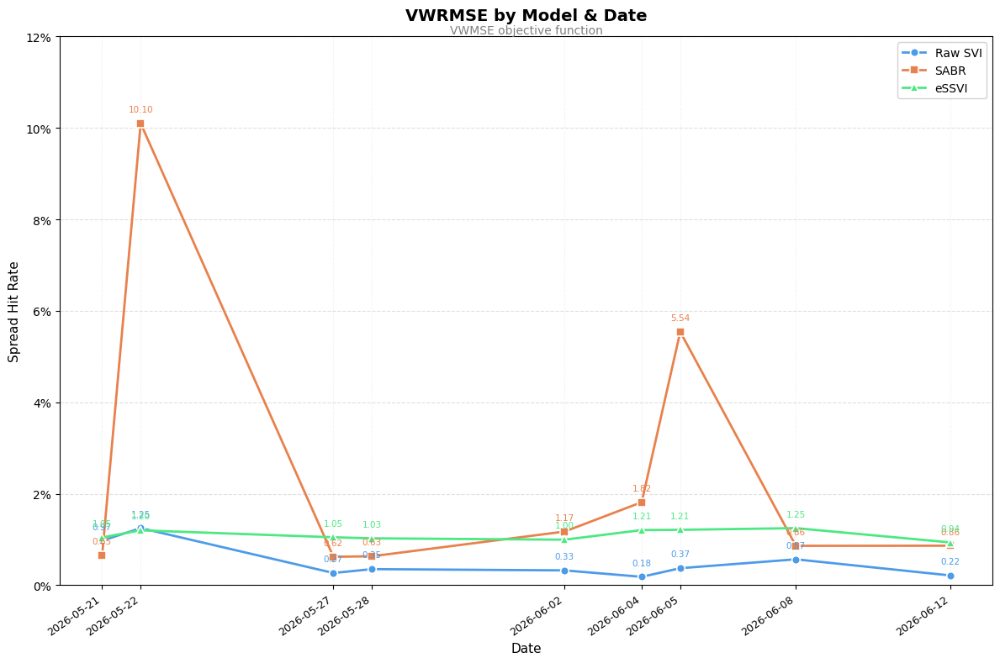

Saved → spread_hit_rate.png


In [23]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
with open('comparison_dict.pkl', 'rb') as f:
    comparison_dict = pickle.load(f)

# Extract dates and hit rates per model
dates = sorted(comparison_dict.keys())
dates_dt = [datetime.strptime(d, '%Y-%m-%d') for d in dates]

models = ['Raw SVI', 'SABR', 'eSSVI']
colors  = {'Raw SVI': '#4C9BE8', 'SABR': '#E8814C', 'eSSVI': '#4CE882'}
markers = {'Raw SVI': 'o',        'SABR': 's',        'eSSVI': '^'}

hit_rates = {m: [] for m in models}

for date in dates:
    hr = comparison_dict[date].vwrmse
    for model in models:
        hit_rates[model].append(hr[model])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for model in models:
    ax.plot(
        dates_dt, hit_rates[model],
        label=model,
        color=colors[model],
        marker=markers[model],
        linewidth=2,
        markersize=7,
        markeredgewidth=1.2,
        markeredgecolor='white',
    )
    # Annotate each point with its value
    for x, y in zip(dates_dt, hit_rates[model]):
        ax.annotate(
            f'{100*y:.2f}',
            xy=(x, y),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=7.5,
            color=colors[model],
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)

ax.set_ylim(0, 0.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax.set_title('VWRMSE by Model & Date', fontsize=14, fontweight='bold', pad=14)
ax.text(0.5, 1.0, 'VWMSE objective function', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.savefig('spread_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spread_hit_rate.png")

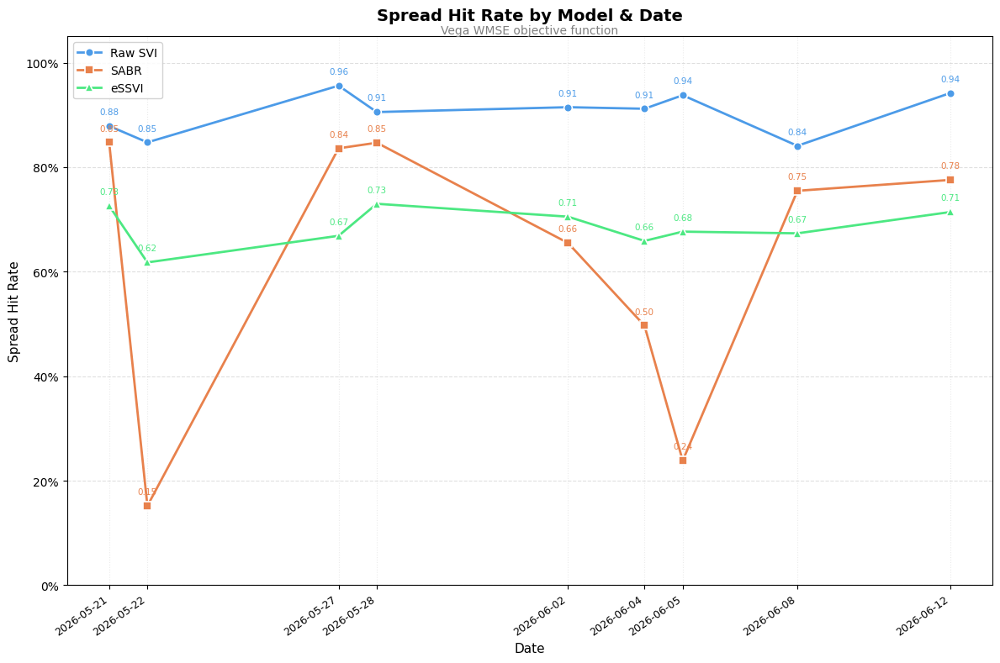

Saved → spread_hit_rate.png


In [85]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
# with open('comparison_dict.pkl', 'rb') as f:
#     comparison_dict = pickle.load(f)

# Extract dates and hit rates per model
dates = sorted(comparison_dict.keys())
dates_dt = [datetime.strptime(d, '%Y-%m-%d') for d in dates]

models = ['Raw SVI', 'SABR', 'eSSVI']
colors  = {'Raw SVI': '#4C9BE8', 'SABR': '#E8814C', 'eSSVI': '#4CE882'}
markers = {'Raw SVI': 'o',        'SABR': 's',        'eSSVI': '^'}

hit_rates = {m: [] for m in models}

for date in dates:
    hr = comparison_dict[date].spread_hit_rate
    for model in models:
        hit_rates[model].append(hr[model])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for model in models:
    ax.plot(
        dates_dt, hit_rates[model],
        label=model,
        color=colors[model],
        marker=markers[model],
        linewidth=2,
        markersize=7,
        markeredgewidth=1.2,
        markeredgecolor='white',
    )
    # Annotate each point with its value
    for x, y in zip(dates_dt, hit_rates[model]):
        ax.annotate(
            f'{y:.2f}',
            xy=(x, y),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=7.5,
            color=colors[model],
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax.set_title('Spread Hit Rate by Model & Date', fontsize=14, fontweight='bold', pad=14)
ax.text(0.5, 1.0, 'Vega WMSE objective function', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.savefig('spread_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spread_hit_rate.png")

eth 2026-06-04 20:06 done
eth 2026-06-05 07:50 done
eth 2026-06-05 11:52 done
eth 2026-06-08 11:49 done
eth 2026-06-12 12:45 done
eth 2026-05-21 13:41 done
eth 2026-05-21 13:42 done
eth 2026-05-21 13:43 done
eth 2026-05-21 13:44 done
eth 2026-05-21 13:45 done
eth 2026-05-22 14:42 done
eth 2026-05-27 11:26 done
eth 2026-05-27 11:43 done
eth 2026-05-28 09:42 done
eth 2026-06-02 07:26 done


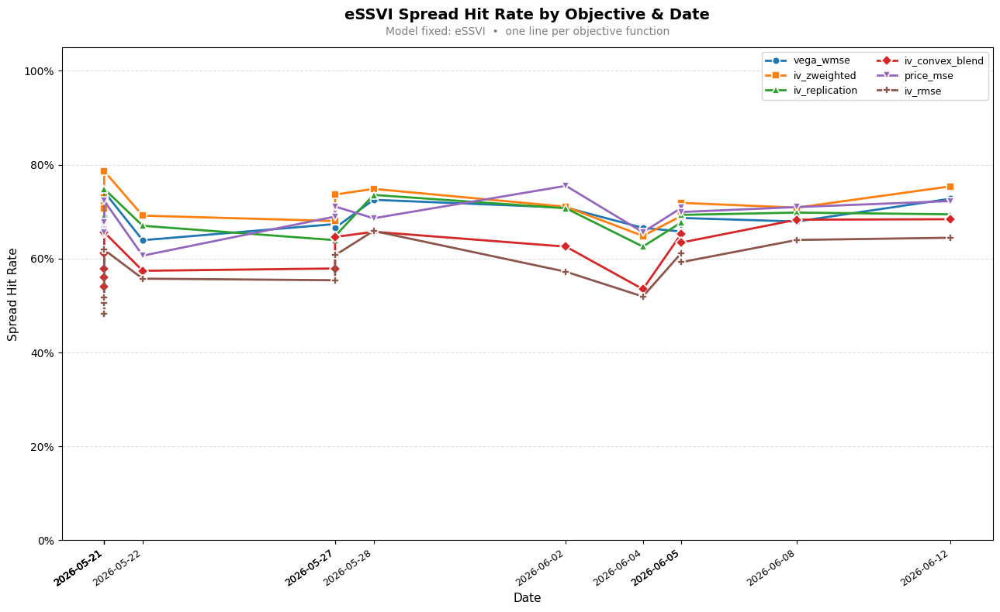

In [74]:
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from volatility_surface.core.calibration.objectives import OBJECTIVES
from volatility_surface.models.vol_models import get_model

obj_names = ['vega_wmse', 'iv_zweighted', 'iv_replication',
             'iv_convex_blend', 'price_mse', 'iv_rmse']        # drop the losers

# ---- gather (cache so you don't recompute) -------------------------------
hit_rates = {o: {} for o in obj_names}        # hit_rates[obj][date_str]
for date_str, snap in eth_snapshots.items():
    snap_clean = snap[(snap.half_spread / snap.mark_price) < 0.5]   # same filter as eth_clean
    for o in obj_names:
        r = calibrate_global_essvi(snap_clean, model=get_model('essvi'),
                                   objective=OBJECTIVES[o],
                                   bid_col='bid_iv', ask_col='ask_iv', verbose=False)
        hit_rates[o][date_str] = np.nanmean(r['metrics']['spread_hit_rate'])
    print(date_str, 'done')

# ---- reshape & sort by date ----------------------------------------------
date_keys = sorted(eth_snapshots, key=lambda k: k.split()[1])
dates_dt  = [datetime.strptime(k.split()[1], '%Y-%m-%d') for k in date_keys]
series    = {o: [hit_rates[o][k] for k in date_keys] for o in obj_names}

# ---- plot -----------------------------------------------------------------
palette = plt.cm.tab10.colors
markers = ['o', 's', '^', 'D', 'v', 'P']
fig, ax = plt.subplots(figsize=(13, 8))
for i, o in enumerate(obj_names):
    ax.plot(dates_dt, series[o], label=o, color=palette[i % 10],
            marker=markers[i % len(markers)], linewidth=2, markersize=7,
            markeredgewidth=1.2, markeredgecolor='white')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('eSSVI Spread Hit Rate by Objective & Date', fontsize=14, fontweight='bold', pad=26)
ax.text(0.5, 1.02, 'Model fixed: eSSVI  •  one line per objective function',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11); ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.legend(fontsize=9, framealpha=0.85, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('essvi_hit_rate_by_objective_date.png', dpi=150, bbox_inches='tight')
plt.show()

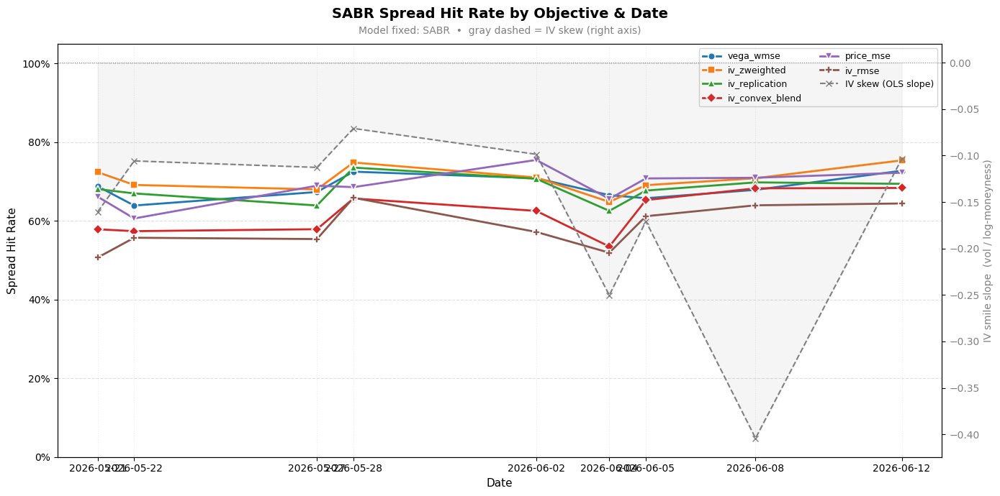

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from scipy import stats

# ── 1. Compute skew per date from raw data (no calibration) ───────────────
seen_dates = set()
daily_snapshots = {}
for key in sorted(eth_snapshots):
    date = key.split()[1]
    if date not in seen_dates:
        seen_dates.add(date)
        daily_snapshots[key] = eth_snapshots[key]

date_keys = sorted(daily_snapshots, key=lambda k: k.split()[1])
dates     = [k.split()[1] for k in date_keys]
dates_dt  = [pd.Timestamp(d) for d in dates]

skews = []
for key in date_keys:
    df = daily_snapshots[key]
    df = df[(df.half_spread / df.mark_price) < 0.5]
    df = df[np.abs(df['k']) < 0.5].dropna(subset=['k', 'mark_iv'])
    if len(df) < 4:
        skews.append(np.nan)
    else:
        slope, *_ = stats.linregress(df['k'], df['mark_iv'])
        skews.append(slope)
skews = np.array(skews)

# ── 2. Plot hit rates (one line per objective) + skew on twin axis ────────
palette = plt.cm.tab10.colors
markers_list = ['o', 's', '^', 'D', 'v', 'P']

fig, ax = plt.subplots(figsize=(14, 7))
ax_skew = ax.twinx()

# Skew in background — plot first so it sits behind the hit-rate lines
ax_skew.fill_between(dates_dt, skews, alpha=0.08, color='gray')
ax_skew.plot(dates_dt, skews, color='gray', lw=1.5, ls='--',
             marker='x', ms=6, label='IV skew (OLS slope)')
ax_skew.set_ylabel('IV smile slope  (vol / log-moneyness)', fontsize=10, color='gray')
ax_skew.tick_params(axis='y', labelcolor='gray')
ax_skew.axhline(0, color='gray', lw=0.8, ls=':')

# Hit-rate lines
for i, o in enumerate(obj_names):
    hr_vals = [hit_rates[o][k] for k in date_keys]
    ax.plot(dates_dt, hr_vals, label=o, color=palette[i % 10],
            marker=markers_list[i % len(markers_list)], linewidth=2, markersize=7,
            markeredgewidth=1.2, markeredgecolor='white', zorder=3)

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.set_title('SABR Spread Hit Rate by Objective & Date', fontsize=14, fontweight='bold', pad=26)
ax.text(0.5, 1.02, 'Model fixed: SABR  •  gray dashed = IV skew (right axis)',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='gray')

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_skew.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, framealpha=0.85, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.savefig('sabr_hit_rate_skew_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
sabr_weird_arbfree = calibrate_snapshot(df=eth_snapshots['eth 2026-05-22 14:42'], model=get_model('sabr'), objective=get_objective('vega_wmse'), bid_col = 'bid_iv', ask_col='ask_iv', verbose=False, enforce_arbfree=True)

In [ ]:

from calibrator import calibrate_global_essvi
obj1 = make_zone_wmse(atm_threshold=0.2, atm_boost=1) #base case, 0 breaks it since it's a mult
obj3 = make_zone_wmse(atm_threshold = 0.2, atm_boost=3)
obj5 = make_zone_wmse(atm_threshold=0.2, atm_boost=5)
result_essvi_1 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj1, verbose=False)
result_essvi_5 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj5, verbose=False)
result_essvi_3 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj3, verbose=False)
# obj1 = make_zone_wmse(atm_threshold=0.15, wing_weight=1)
# result_essvi_w1 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'),objective=obj1, verbose=False)

In [22]:
result_essvi = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=get_objective('iv_rmse'), verbose=False)
result_essvi_vw = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=get_objective('vega_wmse'), verbose=False)

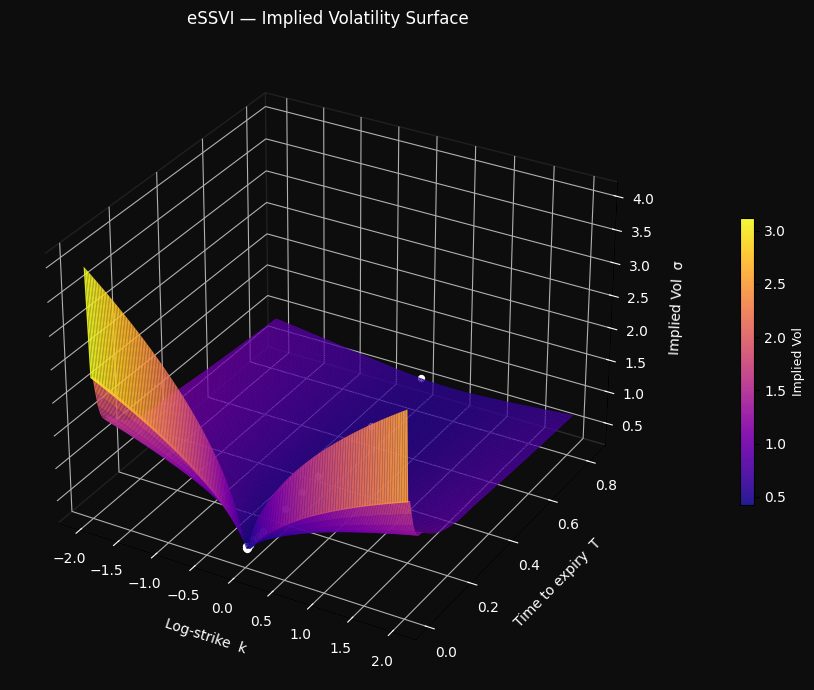

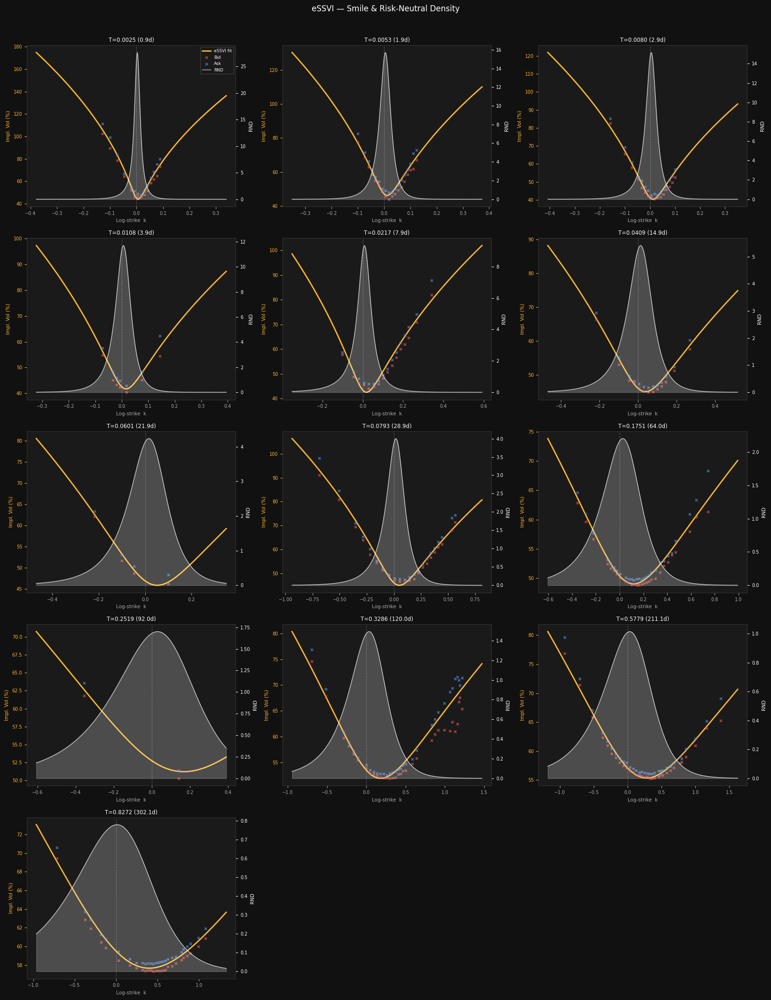

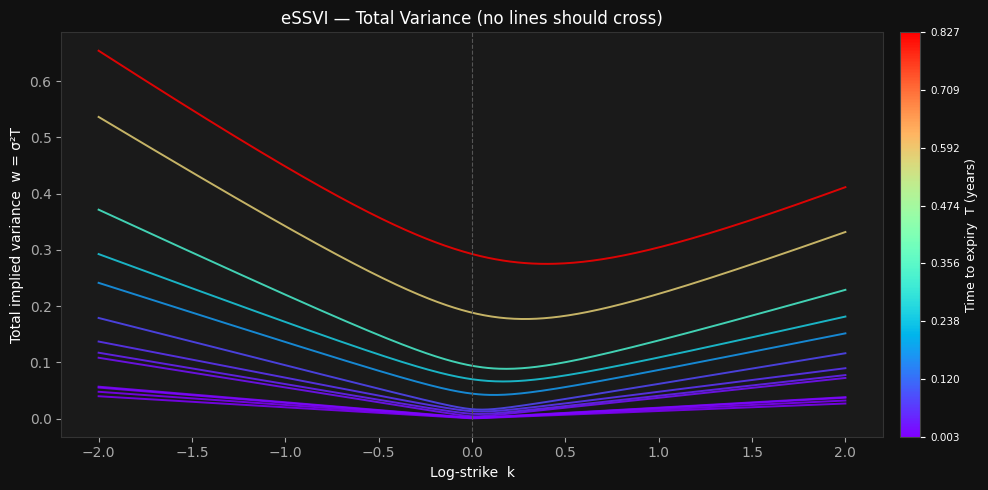

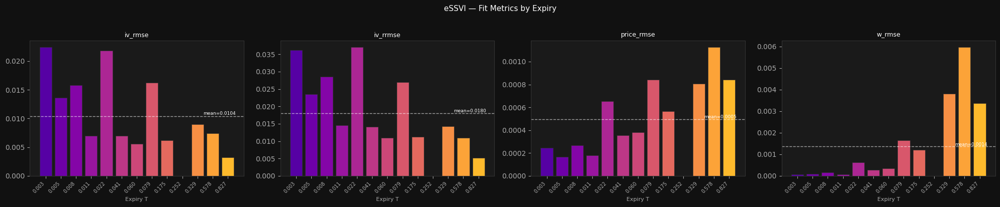

In [21]:
plot_all(result_essvi,df=snapshot); #IV RMSE

By excluding  all options that have not been traded in the last 24 hours, 

Raw
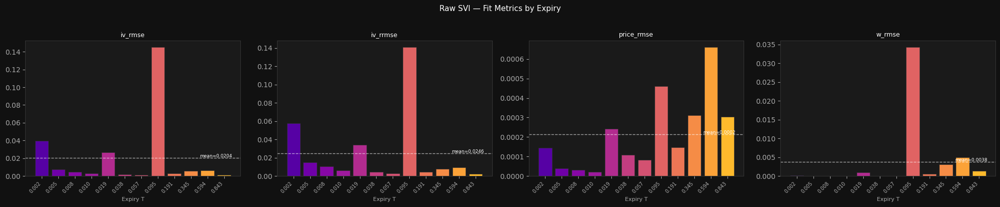

Volume-Filtered : 
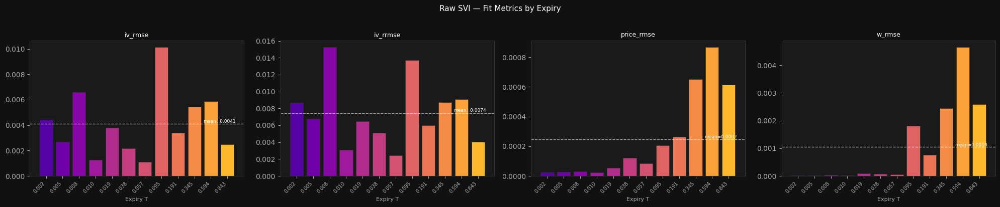

IV RMSE : Reduced by 80% \
IV RRMSE : Reduced by 70% \
Price RMSE: no change -> makes sense because iv improving by 80% on a few percent is extremely small : vega isn't large enough generally to warrant a large change \
W Rmse : Improved by 75%

# MODEL COMPARISON 

In [24]:
models = ['svi','ssvi','essvi','sabr'] 
dict_results = {}
for model in models:
    for obj in ['iv_rmse', 'vega_wmse']:
        match model:
            case 'essvi':
                dict_results[f'{model}_{obj}'] = calibrate_global_essvi(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)
            case 'ssvi':
                dict_results[f'{model}_{obj}'] = calibrate_global_ssvi(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)
            case 'sabr':
                dict_results[f'{model}_{obj}'] = calibrate_snapshot(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)
            case 'svi':
                dict_results[f'{model}_{obj}'] = calibrate_snapshot(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)



## IV RMSE METRIC

(<Figure size 1200x700 with 2 Axes>,
 <Figure size 1650x2100 with 28 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 2000x400 with 4 Axes>)

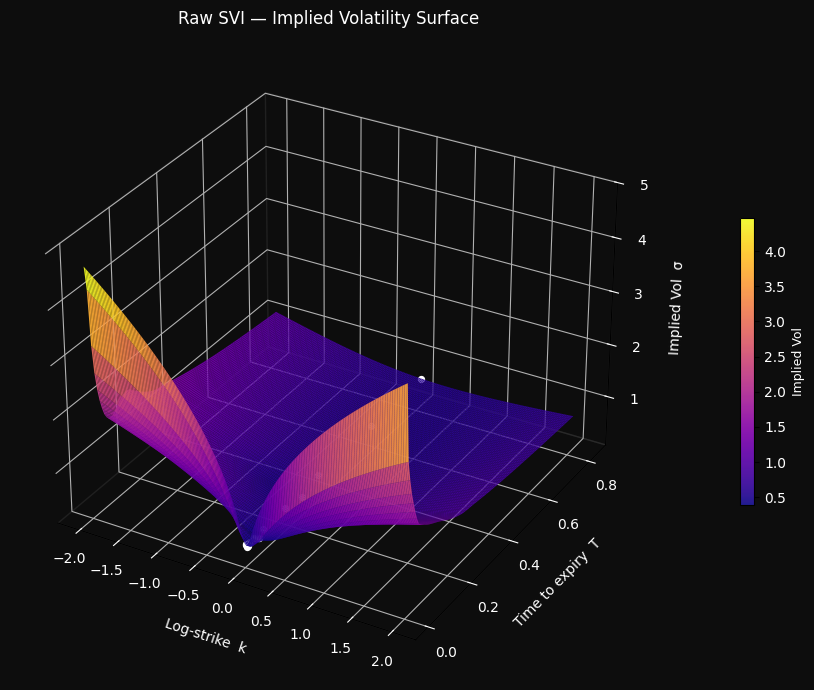

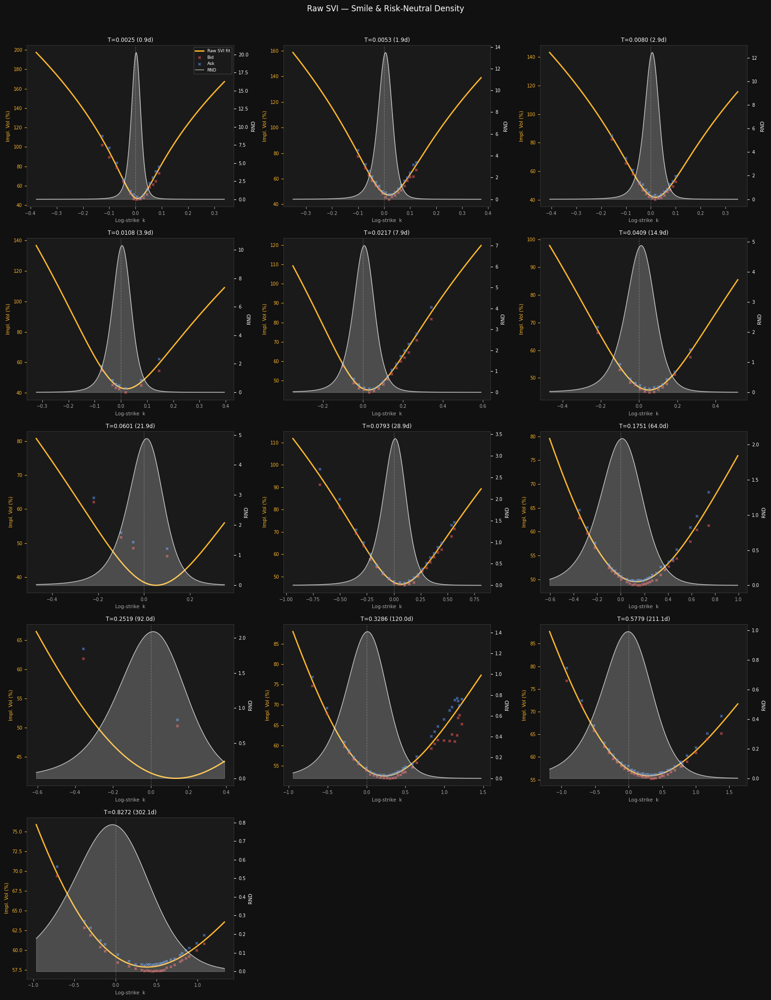

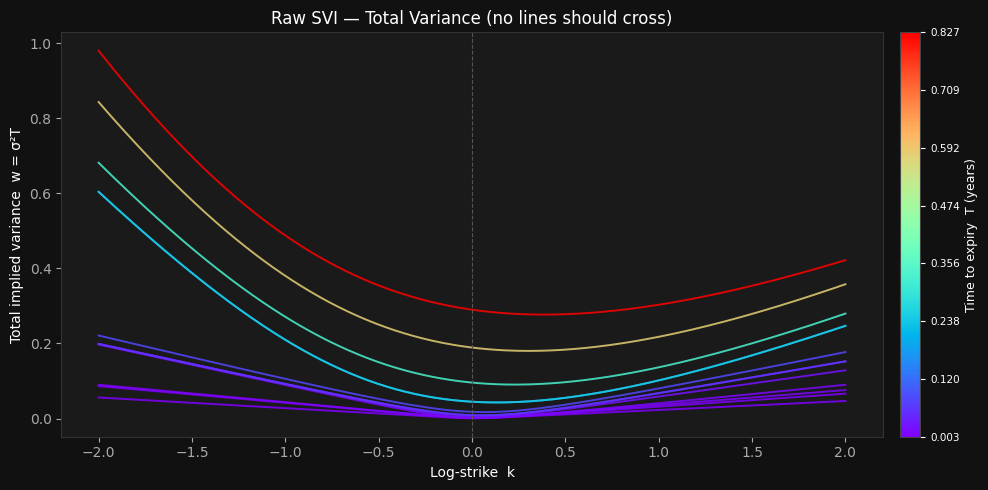

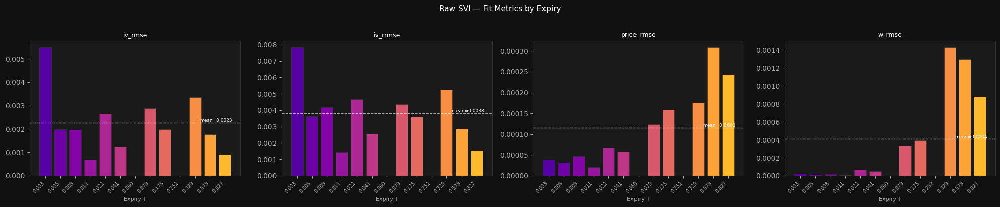

In [32]:
plot_all(dict_results['svi_iv_rmse'], df=snapshot);

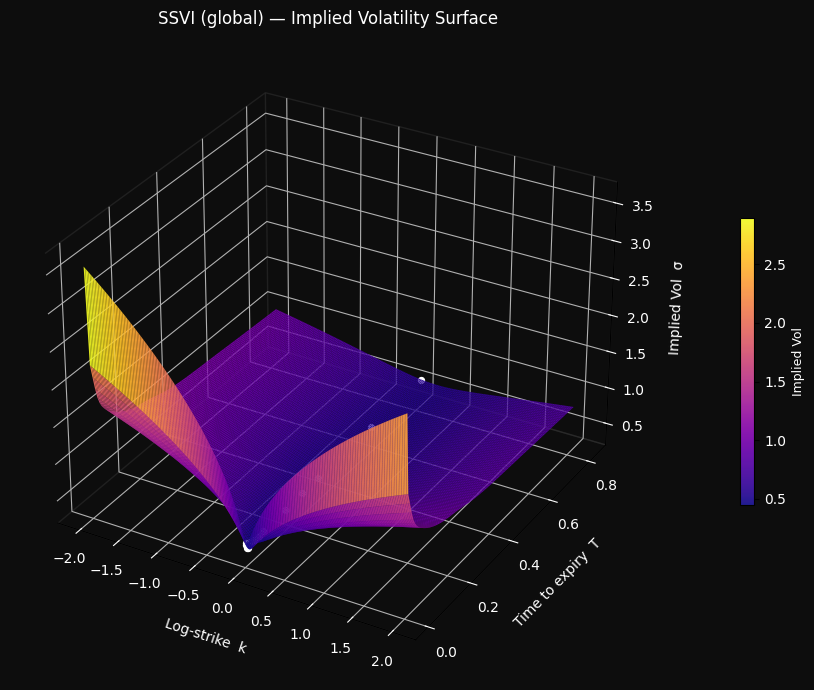

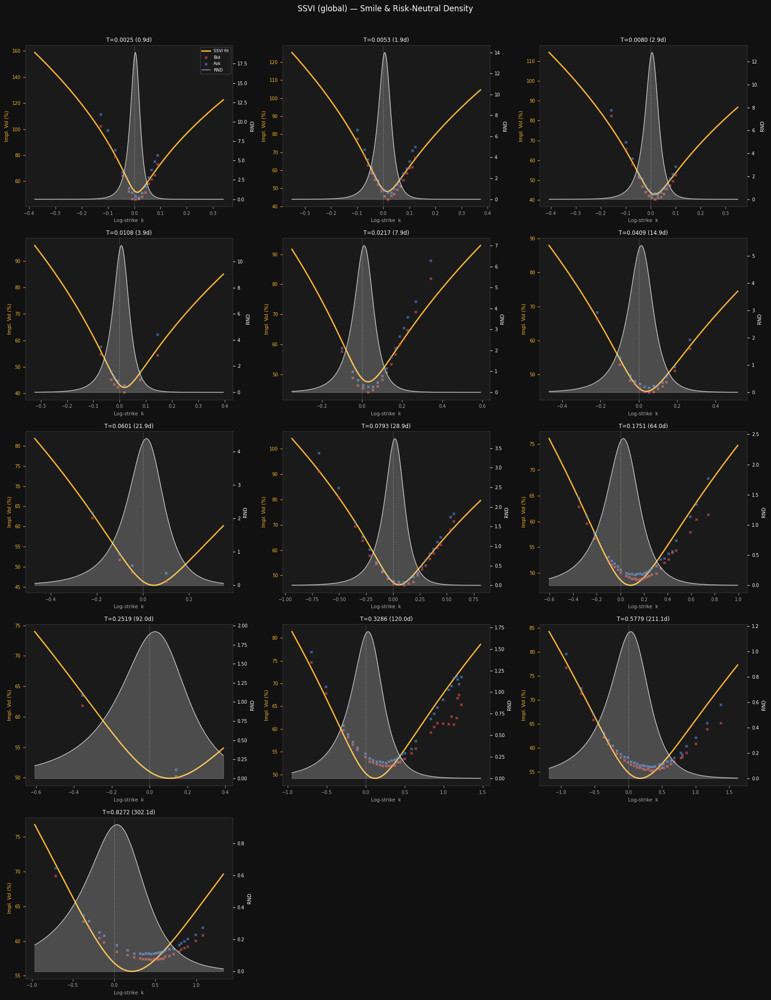

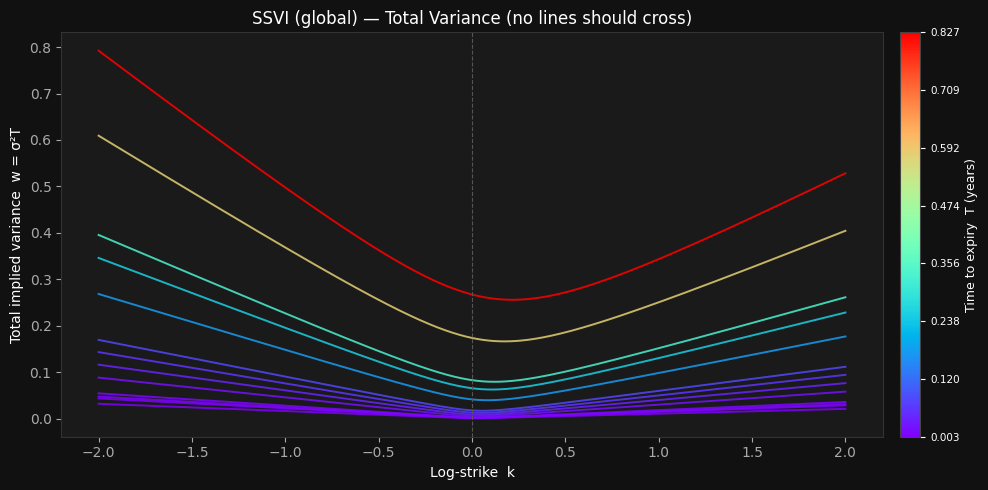

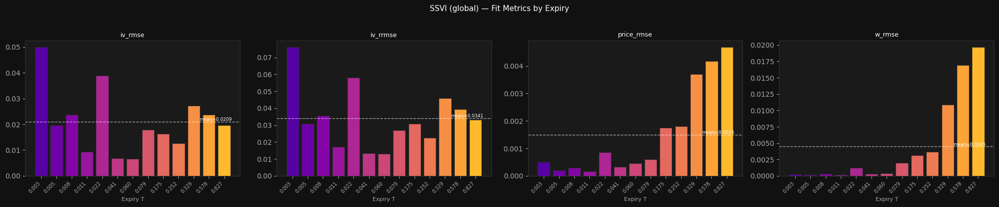

In [33]:
plot_all(dict_results['ssvi_iv_rmse'], df=snapshot);

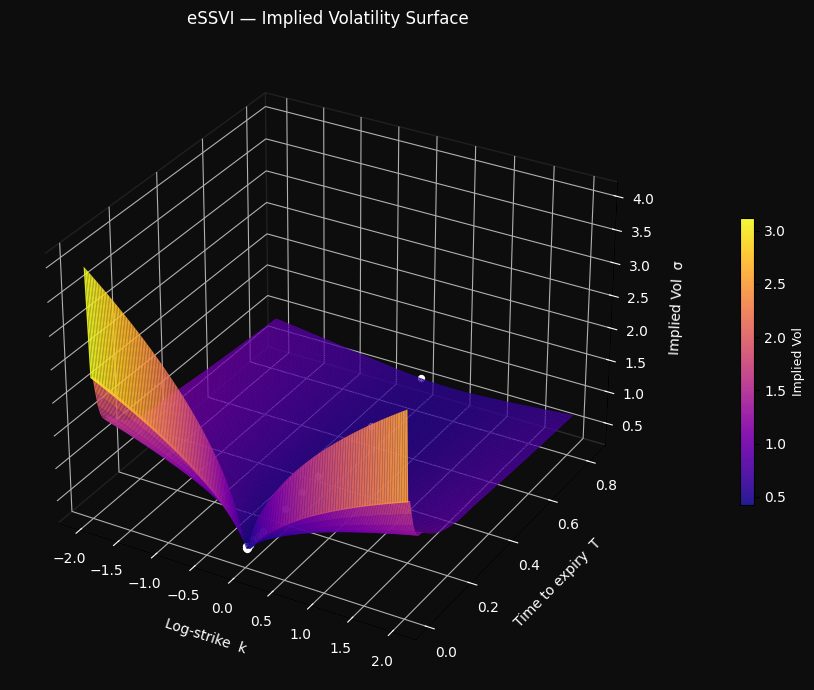

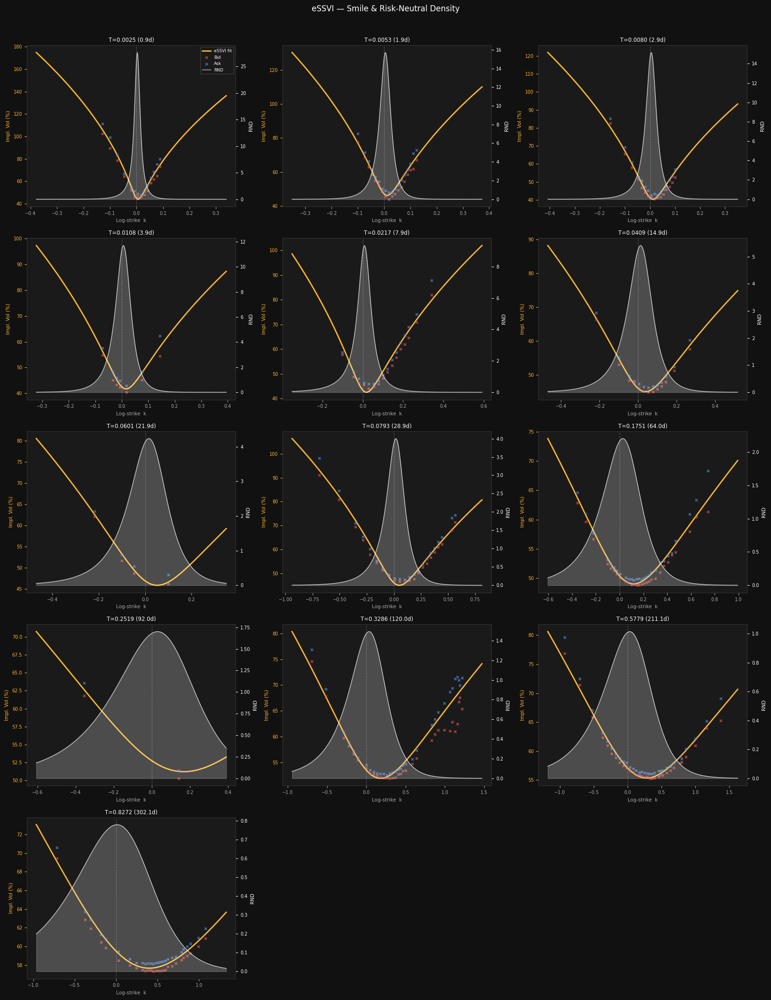

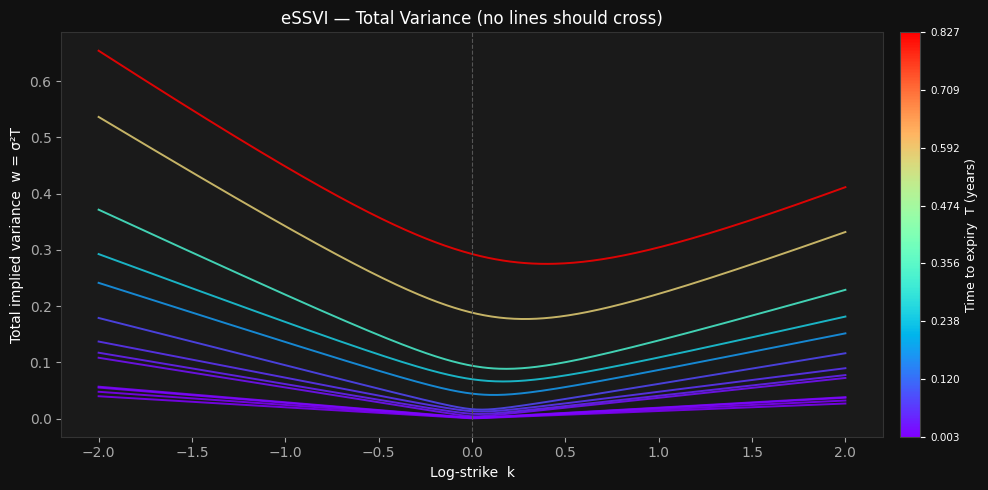

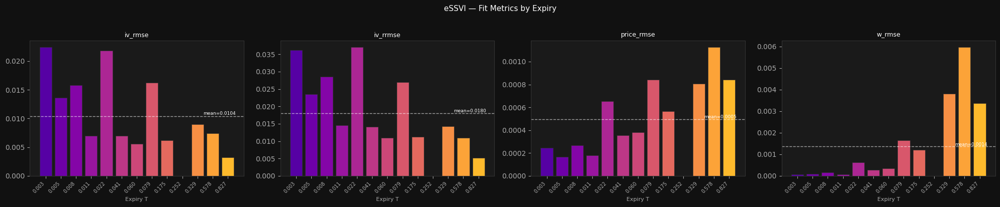

In [34]:
plot_all(dict_results['essvi_iv_rmse'], df=snapshot);

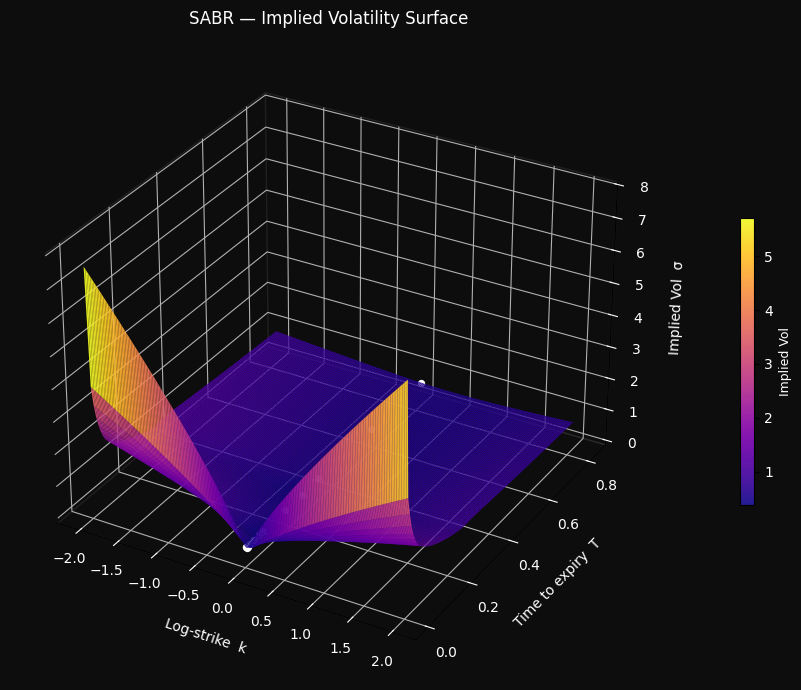

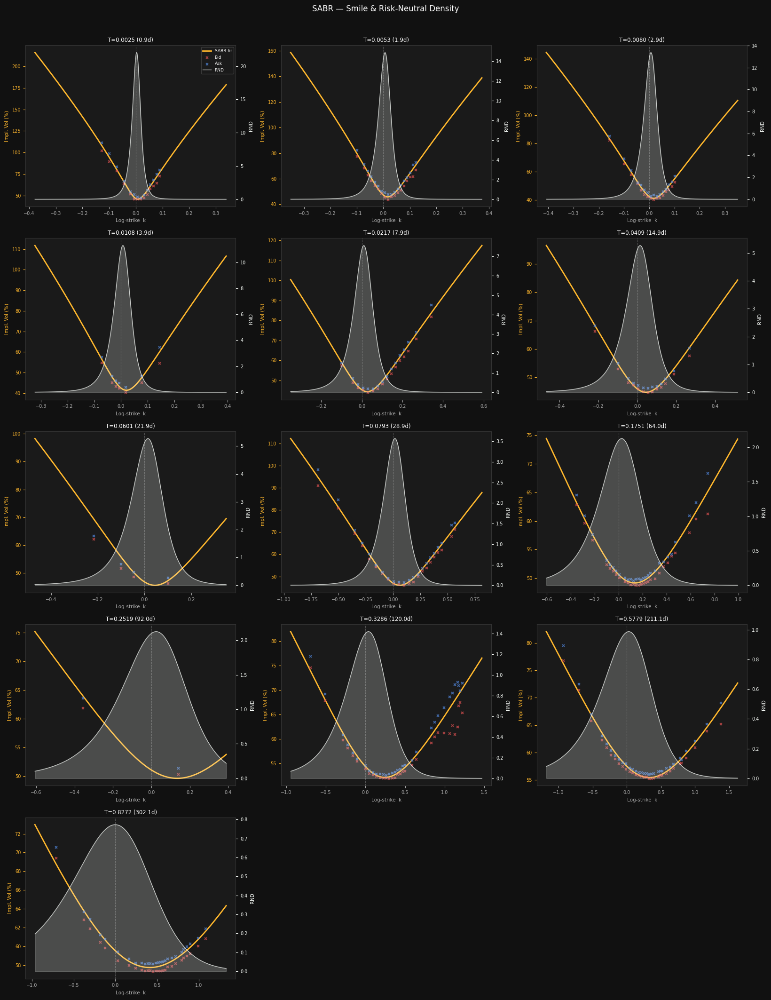

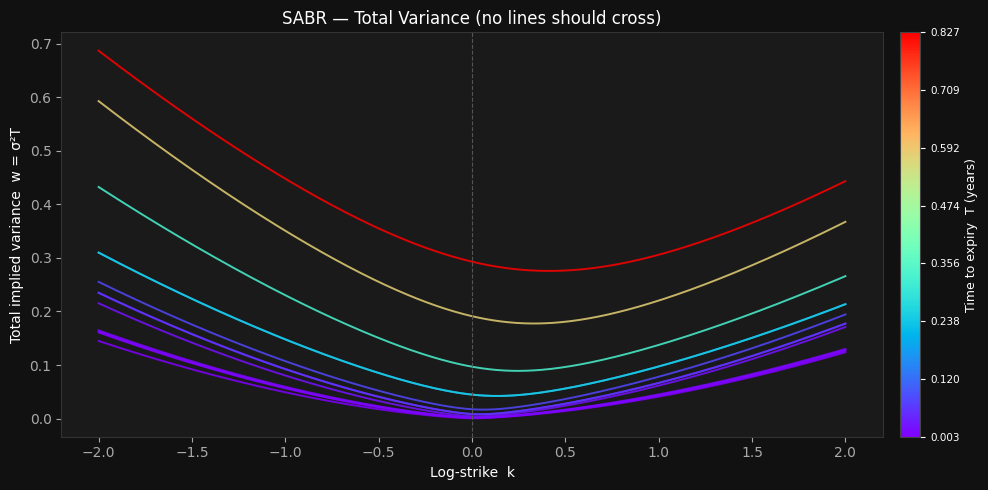

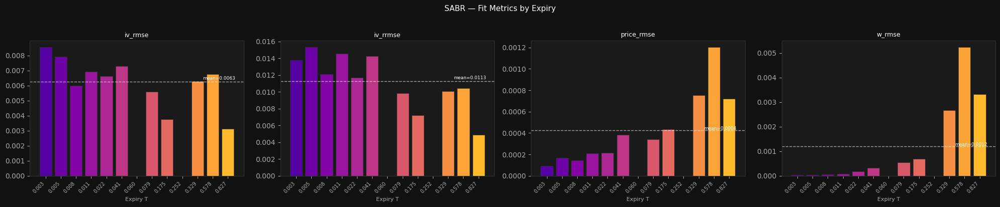

In [35]:
plot_all(dict_results['sabr_iv_rmse'], df=snapshot);

## Vega Weighted MSE

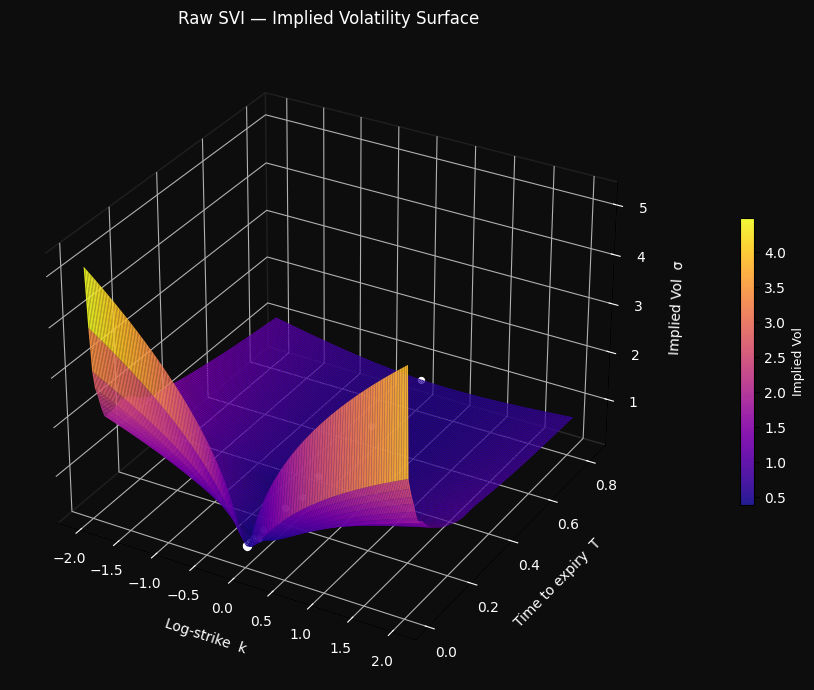

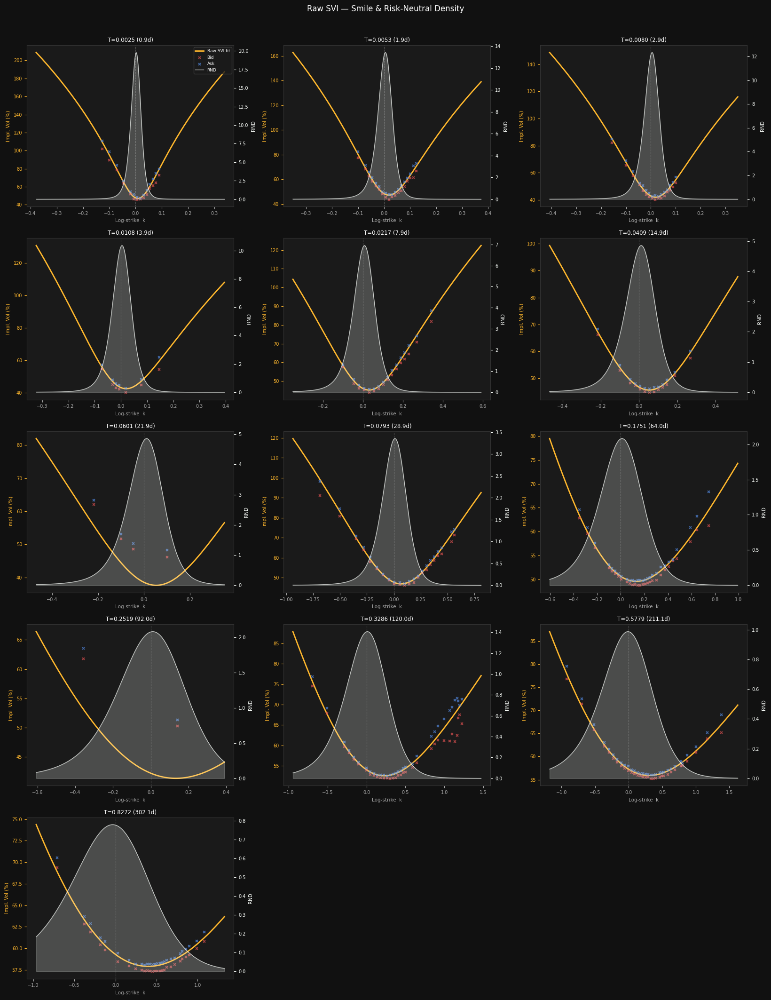

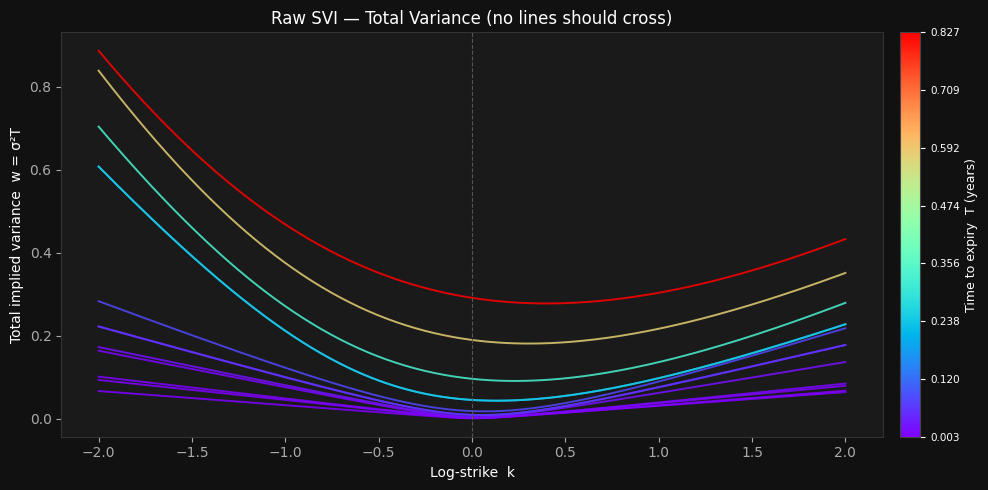

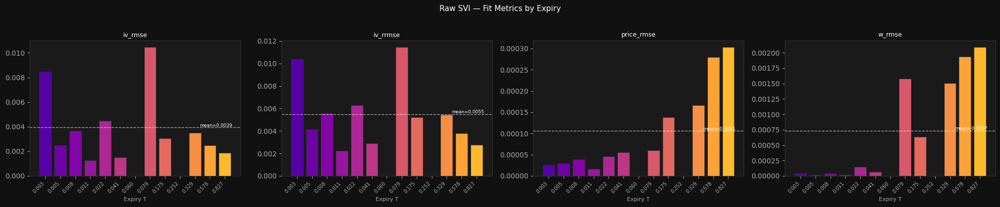

In [36]:
plot_all(dict_results['svi_vega_wmse'], df=snapshot);

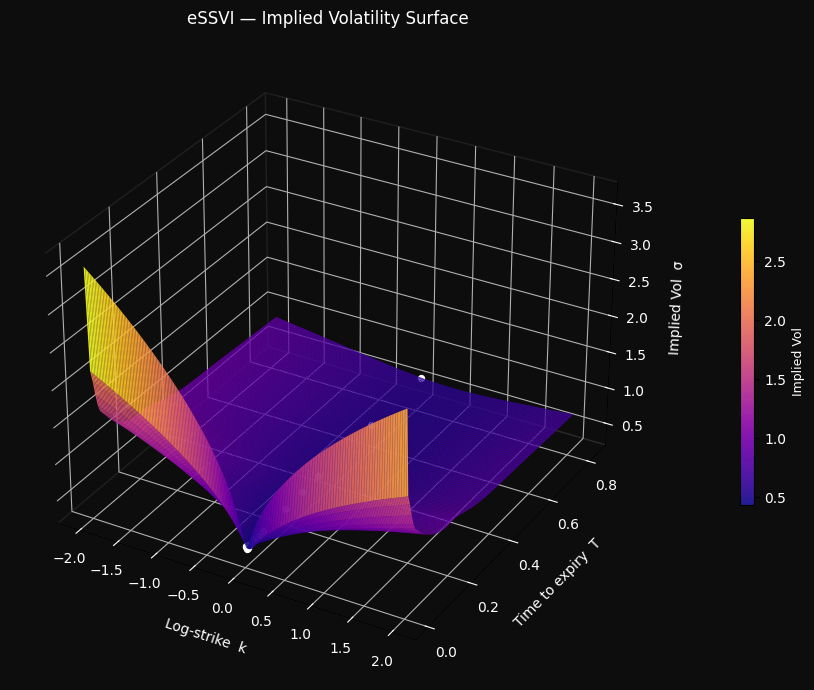

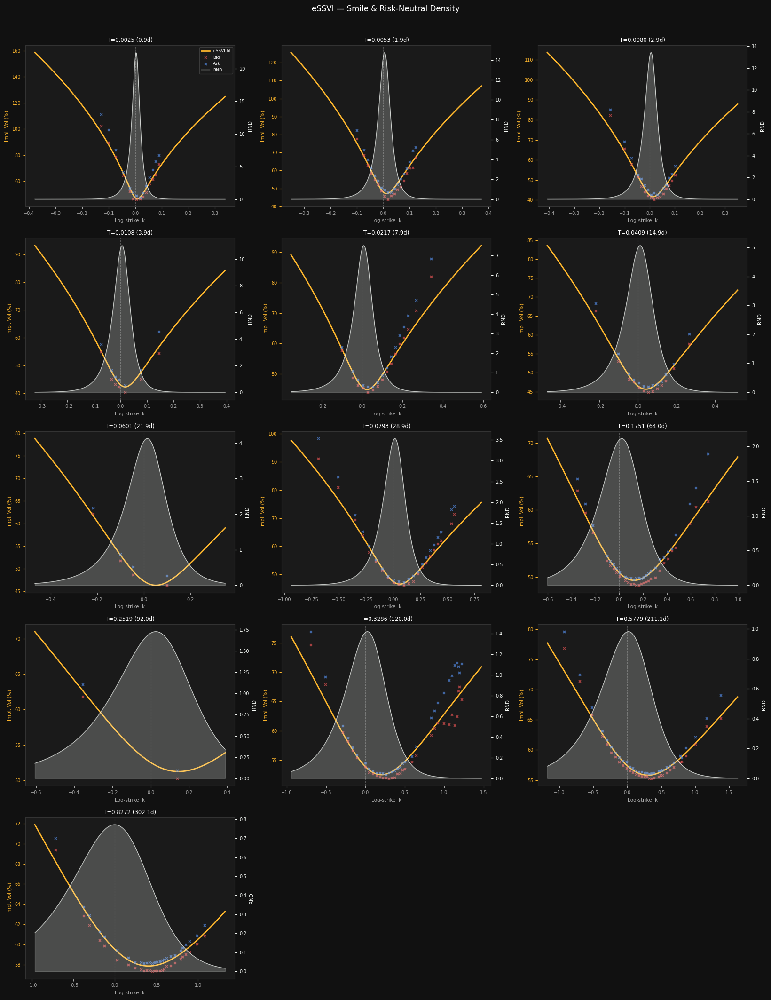

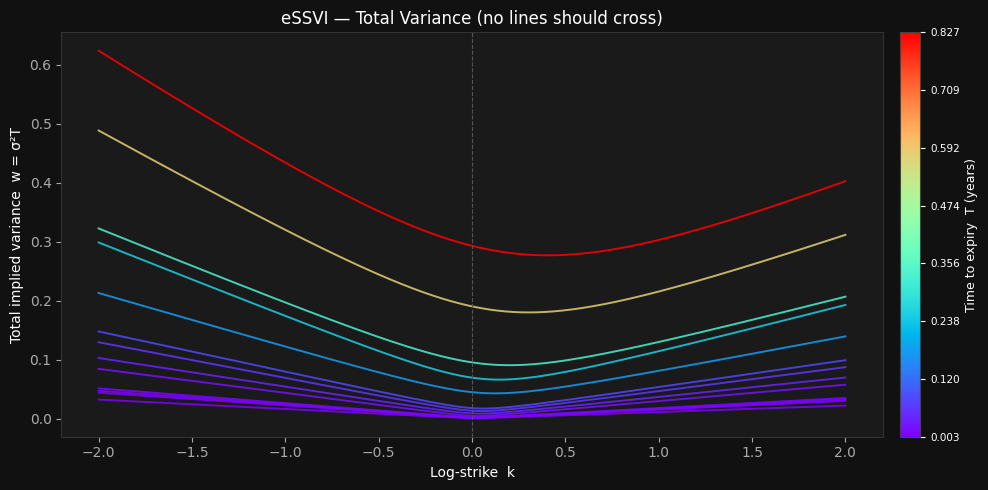

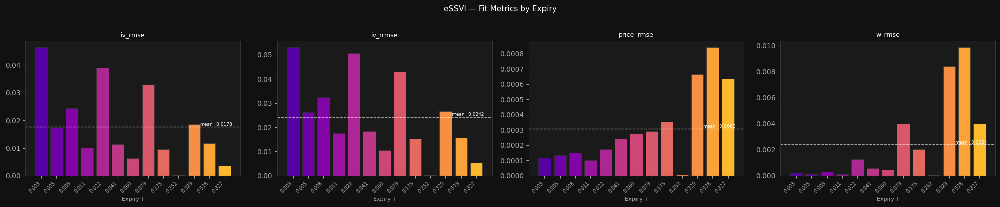

In [38]:
plot_all(dict_results['essvi_vega_wmse'], df=snapshot);

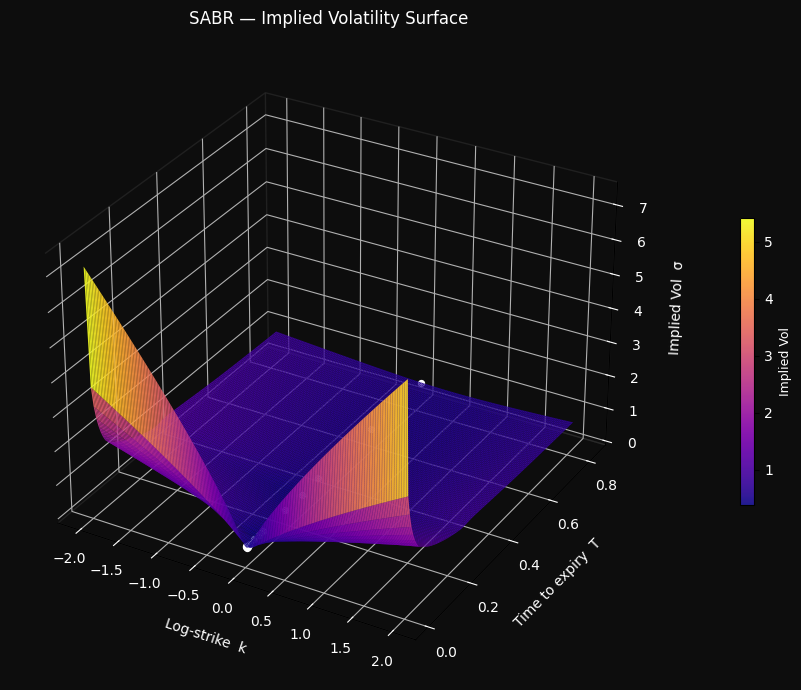

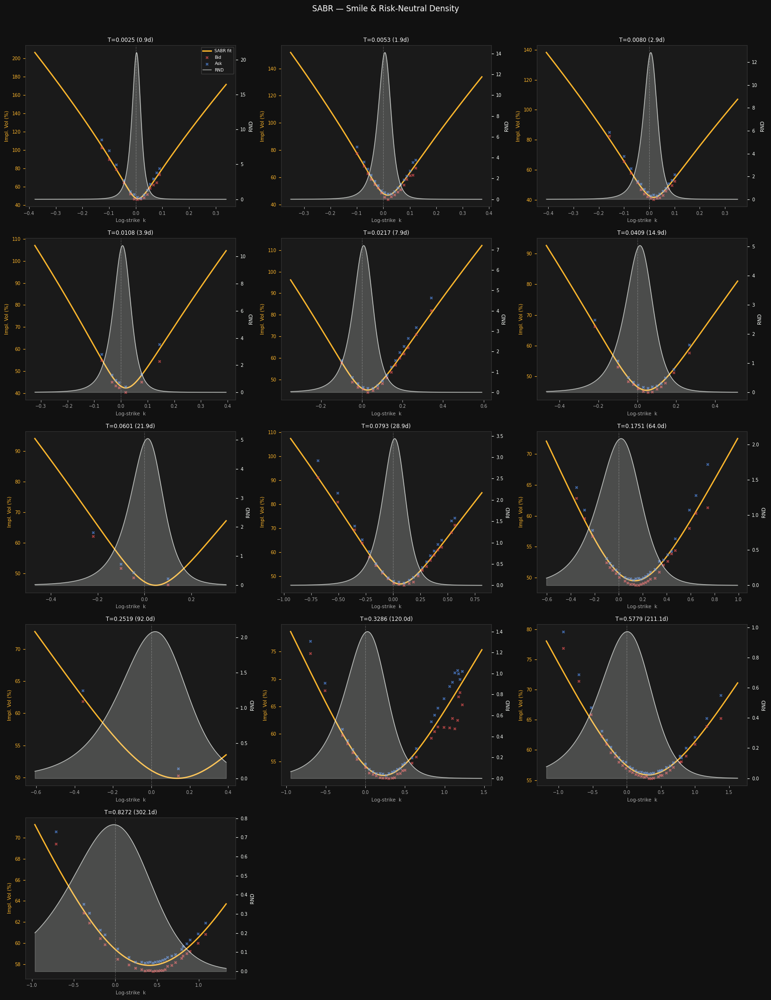

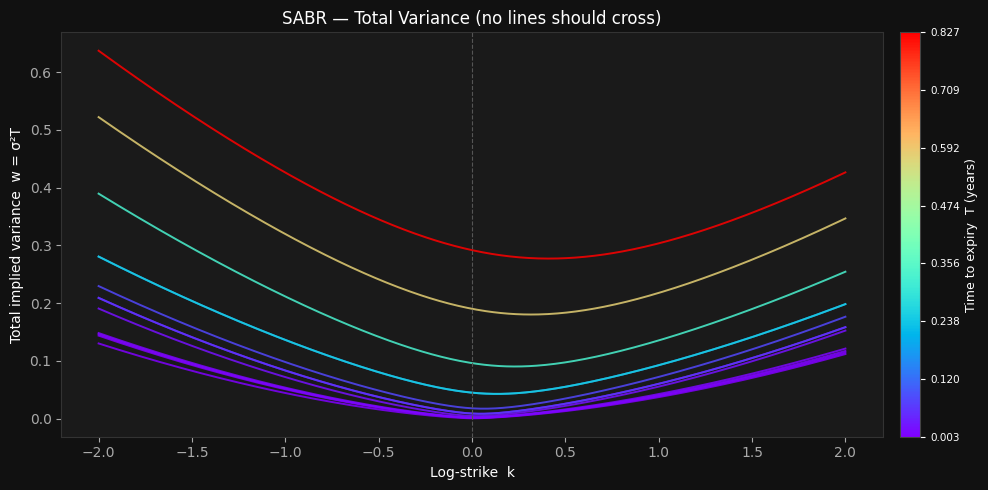

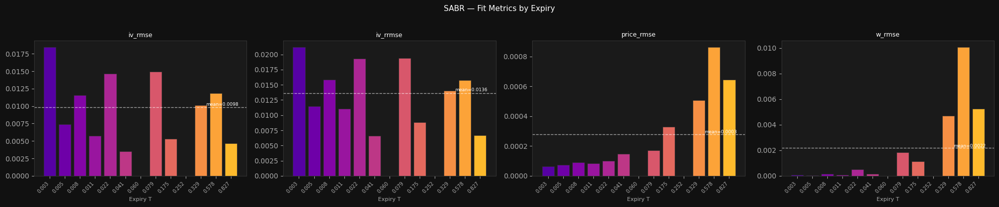

In [39]:
plot_all(dict_results['sabr_vega_wmse'], df=snapshot);

In [ ]:
import pickle
with open('calibration_results/dict_results.pkl','rb') as f:
    dict_results = pickle.load(f)

In [ ]:

from volatility_surface.models.vol_models import get_model
# After calibrating

# Quantitative check
diag = check_arbitrage(result, n_strikes=500, n_times=200)
print(diag["summary"])
if not diag["calendar_free"]:
    print(f"Calendar arb at (k={diag['calendar_worst_k']:.3f}, "
          f"t={diag['calendar_worst_t']:.4f}), worst ∂w/∂t = {diag['calendar_worst']:.2e}")

# Visual diagnostic
plot_arbitrage_map(result)

In [8]:
dict_results.keys()

dict_keys(['svi_iv_rmse', 'svi_vega_wmse', 'ssvi_iv_rmse', 'ssvi_vega_wmse', 'essvi_iv_rmse', 'essvi_vega_wmse', 'sabr_iv_rmse', 'sabr_vega_wmse'])

In [104]:
from volatility_surface.models.vol_models import get_model 
from volatility_surface.core.calibration.objectives import get_objective 
from volatility_surface.core.pricing.volatility_dataframe import implied_volatility_dataframe

from time import time
df1 = clean_df('2 - Data/market_making/eth_2026-06-02_15-27-21.csv')
df2 = clean_df('2 - Data/market_making/eth_2026-06-02_15-27-22.csv')

t1 = time()
init_surf = calibrate_snapshot(df1, model=get_model('essvi'), objective=get_objective('vega_wmse'), verbose=False, penalty_cal=0)
t2 = time()
updated_surf_full_polish = calibrate_global_essvi_update(df2, init_surf, model = get_model('essvi'), objective=get_objective('vega_wmse'), mode='full_polish', verbose=False)
t3 = time()
update_surf_theta = calibrate_global_essvi_update(
    df2, init_surf,
    model=get_model('essvi'),         # ← was 'sabr'
    objective=get_objective('vega_wmse'),
    mode='theta_only', verbose=False,
)
t4 = time()

print(f'Initial calibration of essvi takes {round(t2-t1,2)}s')
print(f'Full polish update of essvi takes {round(t3-t2,2)}s')
print(f'Theta only update of essvi takes {round(t4-t3,2)}s')

Initial calibration of essvi takes 16.86s
Full polish update of essvi takes 1.01s
Theta only update of essvi takes 0.03s


# LOOK AT WHY VEGA WMSE PERFORMS SO MUCH WORSE THAN IV RMSE ON SABR

In [98]:
from volatility_surface.utils.arbitrage_checker import check_arbitrage, plot_arbitrage_map
diag = check_arbitrage(result_no_arb_cond, n_strikes=500, n_times=400)
print(diag['summary'])


NameError: name 'result_no_arb_cond' is not defined

In [13]:
csv_files = sorted(glob.glob(f'data/eth/*.csv'))
arbitrageable = []
no_arb_dict = {}
for file in csv_files:
    df1 = clean_df(f'/Users/macbookair/Internship Natixis/{file}')

    result_no_arb_cond = calibrate_snapshot(df1, model=get_model("sabr"), objective=get_objective('iv_rmse'), verbose=False)
    
    diag = check_arbitrage(result_no_arb_cond, n_strikes=500, n_times=400)
    if diag['calendar_free'] and diag['butterfly_free']:
        print(f' {file} is Arbitrage free')
    else:
        result_arb_cond = calibrate_snapshot(df1, model=get_model("sabr"), objective=get_objective('iv_rmse'), enforce_arbfree=True,verbose=False)
        second_diag =check_arbitrage(result_arb_cond, n_strikes=500, n_times=400)
        if second_diag['calendar_free'] and second_diag['butterfly_free']:
            print(f'/_\ {file} is  Arbitrage free after arb enforcement')
        else:
            print(f'-- {file} is not arbitrage free : cal {second_diag['calendar_free']}, butterfly: {second_diag['butterfly_free']}')

-- data/eth/eth_2026-06-04_22-06.csv is not arbitrage free : cal True, butterfly: False
 data/eth/eth_2026-06-05_09-50.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-21_15h41m.csv is Arbitrage free
-- data/eth/eth_option_data_2026-05-21_15h42m.csv is not arbitrage free : cal False, butterfly: True
 data/eth/eth_option_data_2026-05-21_15h43m.csv is Arbitrage free
-- data/eth/eth_option_data_2026-05-21_15h44m.csv is not arbitrage free : cal False, butterfly: True
-- data/eth/eth_option_data_2026-05-21_15h45m.csv is not arbitrage free : cal False, butterfly: True
 data/eth/eth_option_data_2026-05-22_16h42m.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-27_13h26m.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-27_13h43m.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-28_11h42m.csv is Arbitrage free
 data/eth/eth_option_data_2026-06-02_09h26m.csv is Arbitrage free


In [17]:
df_test = clean_df('data/eth/eth_option_data_2026-05-21_15h42m.csv')
res = calibrate_snapshot(df_test, model=get_model('sabr'), objective=get_objective('vega_wmse'), enforce_arbfree=True, verbose=False)
res_arb = calibrate_snapshot(df_test, model=get_model('sabr'), objective=get_objective('vega_wmse'), verbose=False)
check_arbitrage(res), check_arbitrage(res_arb)

({'calendar_free': True,
  'butterfly_free': True,
  'calendar_worst': 0.08344127820048164,
  'calendar_worst_k': -0.004008016032064354,
  'calendar_worst_t': 0.006329229963076418,
  'calendar_violation_pct': 0.0,
  'butterfly_worst': 0.03175549210158685,
  'butterfly_worst_k': 2.0,
  'butterfly_worst_t': 0.0020888499809741247,
  'butterfly_violation_pct': 0.0,
  'summary': '──────────────────────────────────────────────────────────────────────────────\n  Static-arbitrage check — SABR\n  Grid: 500 strikes × 200 maturities   (k ∈ [-2, 2],  t ∈ [0.0021, 0.8459])\n  FD steps: dk=0.001  dt=0.0005     tolerance=1e-06\n──────────────────────────────────────────────────────────────────────────────\n  Calendar  [PASS]  worst ∂w/∂t = +8.344e-02  @ (k=-0.004, t=0.0063)  violations: 0.000% of grid\n  Butterfly [PASS]  worst g      = +3.176e-02  @ (k=+2.000, t=0.0021)  violations: 0.000% of grid\n──────────────────────────────────────────────────────────────────────────────'},
 {'calendar_free': T